# House Price Prediction Model

This notebook implements three regression models to predict house prices:
1. Simple Linear Regression
2. Random Forest Regression
3. XGBoost Regression

It also includes visualization of the dataset and model performance.

### Requirements
Please ensure you have the following libraries installed:
```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## 1. Data Loading and Preprocessing

In [2]:
# Load the dataset
file_path = 'model_training/data/train.csv'
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


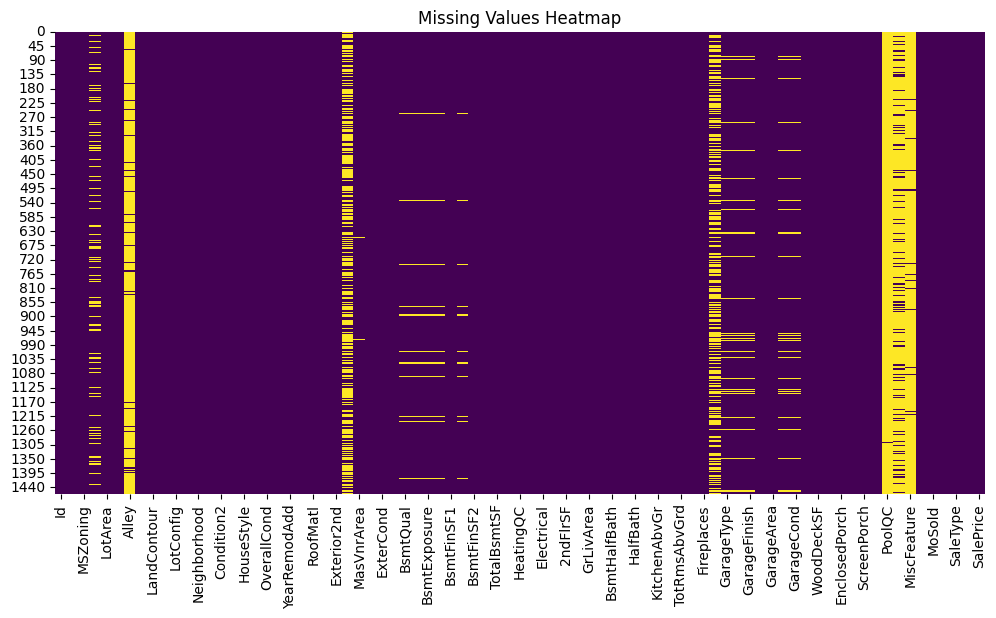

In [5]:
# Check for missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# Data Preprocessing

# Select numeric features and target
# For simplicity in this demo, we tackle numeric columns and fill missing values

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing numeric values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna('Missing')

# Drop 'Id' column as it is not useful for prediction
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# One-hot encoding for categorical variables
df = pd.get_dummies(df, drop_first=True)

print("Shape after preprocessing:", df.shape)

## 2. Visualization

### Heatmap (Correlation)

In [6]:
plt.figure(figsize=(12, 10))
# Calculate correlation
corrmat = df.corr()
# Select top features correlated with SalePrice (absolute correlation > 0.5)
top_corr_features = corrmat.index[abs(corrmat['SalePrice']) > 0.5]
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Features > 0.5 correlation with SalePrice)')
plt.show()

ValueError: could not convert string to float: 'RL'

<Figure size 1200x1000 with 0 Axes>

### Scatter Plot

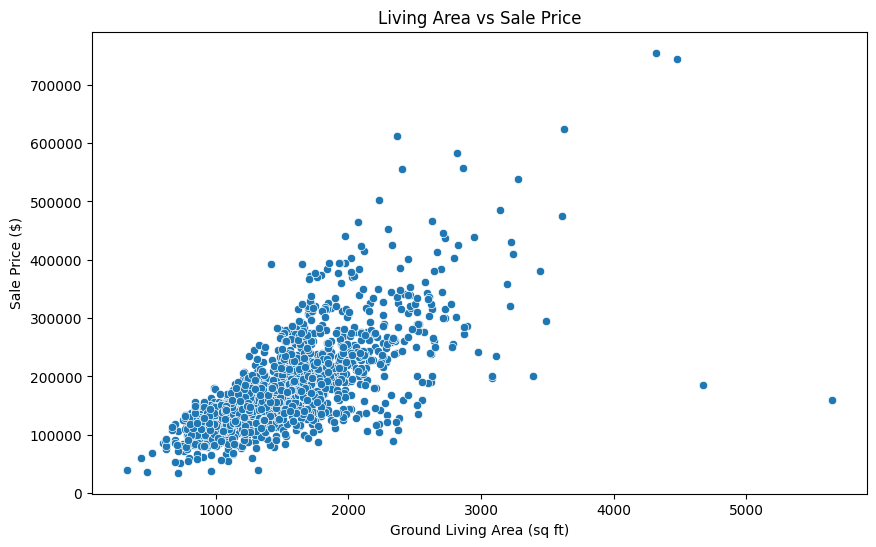

In [7]:
# GrLivArea vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Living Area vs Sale Price')
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

### Distribution of Sale Prices

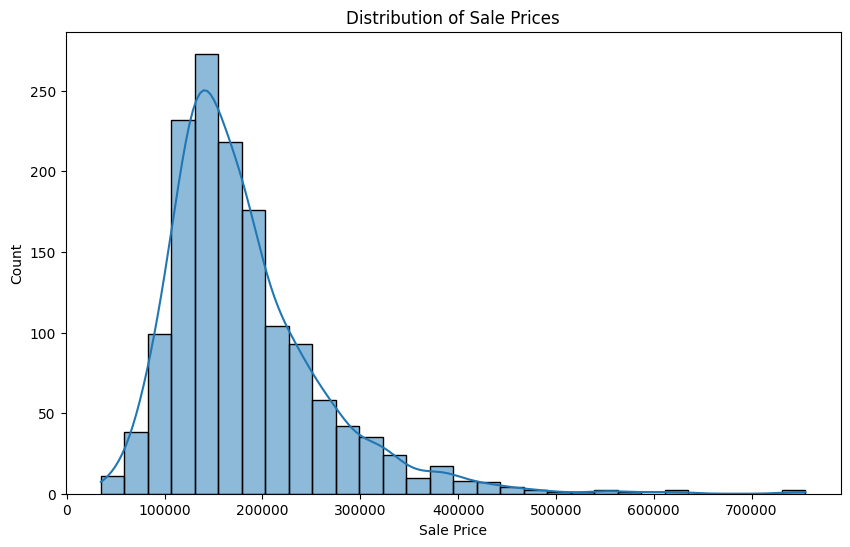

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.show()

## 3. Model Training and Prediction

In [9]:
# Split data
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1168, 80)
Testing set shape: (292, 80)


### 1. Simple Linear Regression
Using Simple Linear Regression for training the data as requested.

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Linear Regression Performance:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

ValueError: could not convert string to float: 'RL'

### 2. Random Forest Regression
Using Random Forest Regression for prediction.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Performance:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

### 3. XGBoost Regression
Using XGBoost Algorithm for prediction.

In [ ]:
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=4, random_state=42)
# Simple fit without early stopping for robustness if eval set issues arise
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Performance:")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 Score:", r2_score(y_test, xgb_pred))

## 4. Model Comparison Visualization

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, color='blue', label='Random Forest Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.legend()
plt.show()